# PROJET MPOX RDC - MASTER 2 DATA SCIENCE
# MODÉLISATION PAR RÉGRESSION LINÉAIRE MULTIPLE
# STEPHIN MBOKOLO MBAKA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV, ElasticNetCV
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [3]:
# Configuration générale des visual...
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 110

In [4]:
# 1. CHARGEMENT ET AUDIT INITIAL DES DONNÉES
chemin_donnees = r"D:\INOHA_MASG\MASTER_2\Mes_projets_data_Sciences_INOHA\INOHA-DataScience-M2\donnees_mpox_RDC_3000.csv"
dataset_mpox = pd.read_csv(chemin_donnees)

In [5]:
print("=" * 70)
print("AUDIT DE LA BASE DE DONNÉES MPOX RDC")
print("=" * 70)
print(f"Dimensions : {dataset_mpox.shape[0]} d'enregistrements | {dataset_mpox.shape[1]} d'attributs\n")

AUDIT DE LA BASE DE DONNÉES MPOX RDC
Dimensions : 3000 d'enregistrements | 17 d'attributs



In [6]:
# Inspection des informations structurales et valeurs manquantes
print("--- Contrôle de complétude ---")
print(dataset_mpox.isnull().sum().to_frame(name="Manquants"))

--- Contrôle de complétude ---
                          Manquants
ID                                0
Semaine                           0
Province                          0
Pluviometrie_mm                   0
Temperature_C                     0
NDVI                              0
Humidite_pct                      0
Densite_Population                0
Couverture_Vaccinale_pct          0
Tests_Realises                    0
Distance_Centre_Sante_km          0
Reservoirs_Animaux                0
Mobilite_Humaine                  0
Cas_Confirmes                     0
Saison                            0
Population_Risque                 0
Taux_Positivite_pct               0


In [7]:
# Encodage ordinal de la variable Saison
encoder_saison = LabelEncoder()
dataset_mpox['Saison'] = encoder_saison.fit_transform(dataset_mpox['Saison'])

In [8]:
correspondance_saisons = dict(zip(encoder_saison.classes_, encoder_saison.transform(encoder_saison.classes_)))
print("\nMapping de la variable Saison :", correspondance_saisons)


Mapping de la variable Saison : {'Pluie': 0, 'Seche': 1}


In [9]:
# 2. EXPLORATION STATISTIQUE ET DIAGNOSTIC
attributs_numeriques = [
    'Semaine', 'Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct',
    'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises',
    'Distance_Centre_Sante_km', 'Reservoirs_Animaux', 'Mobilite_Humaine',
    'Cas_Confirmes', 'Saison', 'Population_Risque', 'Taux_Positivite_pct'
]

In [10]:
# Calcul de la matrice de corrélation de Pearson
matrice_corr = dataset_mpox[attributs_numeriques].corr()

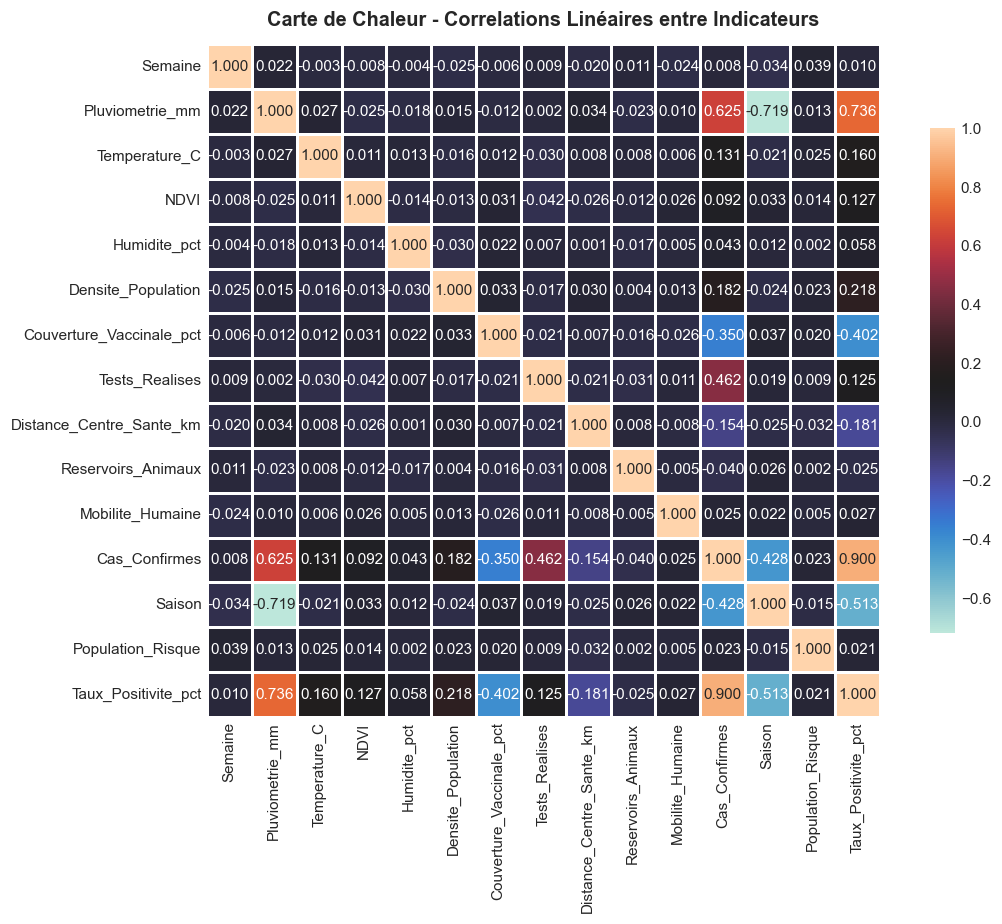

In [13]:
# Visualisation 2.1 : Heatmap de Corrélation (Thème Coolwarm Inversé / Icefire)
fig, ax = plt.subplots(figsize=(11, 8.5))
mask = np.triu(np.ones_like(matrice_corr, dtype=bool)) # Masquage de la diagonale supérieure pour clarté
sns.heatmap(
    matrice_corr, 
    annot=True, 
    fmt=".3f", 
    cmap="icefire", 
    square=True, 
    linewidths=0.8, 
    cbar_kws={"shrink": 0.75},
    ax=ax
)

ax.set_title("Carte de Chaleur - Correlations Linéaires entre Indicateurs", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [16]:
# Diagnostic de Multicolinéarité (Facteur d'Inflation de la Variance - VIF)
predicteurs_vif = [col for col in attributs_numeriques if col not in ['Cas_Confirmes', 'Taux_Positivite_pct']]
X_vif_check = add_constant(dataset_mpox[predicteurs_vif])

tableau_vif = pd.DataFrame({
    "Indicateur": X_vif_check.columns,
    "VIF_Score": [variance_inflation_factor(X_vif_check.values, idx) for idx in range(X_vif_check.shape[1])]
}).sort_values(by="VIF_Score", ascending=False)

print("\n--- Diagnostic VIF (Multicolinéarité) ---")
print(tableau_vif.to_string(index=False))


--- Diagnostic VIF (Multicolinéarité) ---
              Indicateur  VIF_Score
                   const 130.235761
                  Saison   2.082850
         Pluviometrie_mm   2.077131
Couverture_Vaccinale_pct   1.006651
                    NDVI   1.006064
          Tests_Realises   1.006055
      Densite_Population   1.005796
Distance_Centre_Sante_km   1.004751
       Population_Risque   1.004657
                 Semaine   1.004591
        Mobilite_Humaine   1.004321
           Temperature_C   1.003157
      Reservoirs_Animaux   1.002793
            Humidite_pct   1.002531


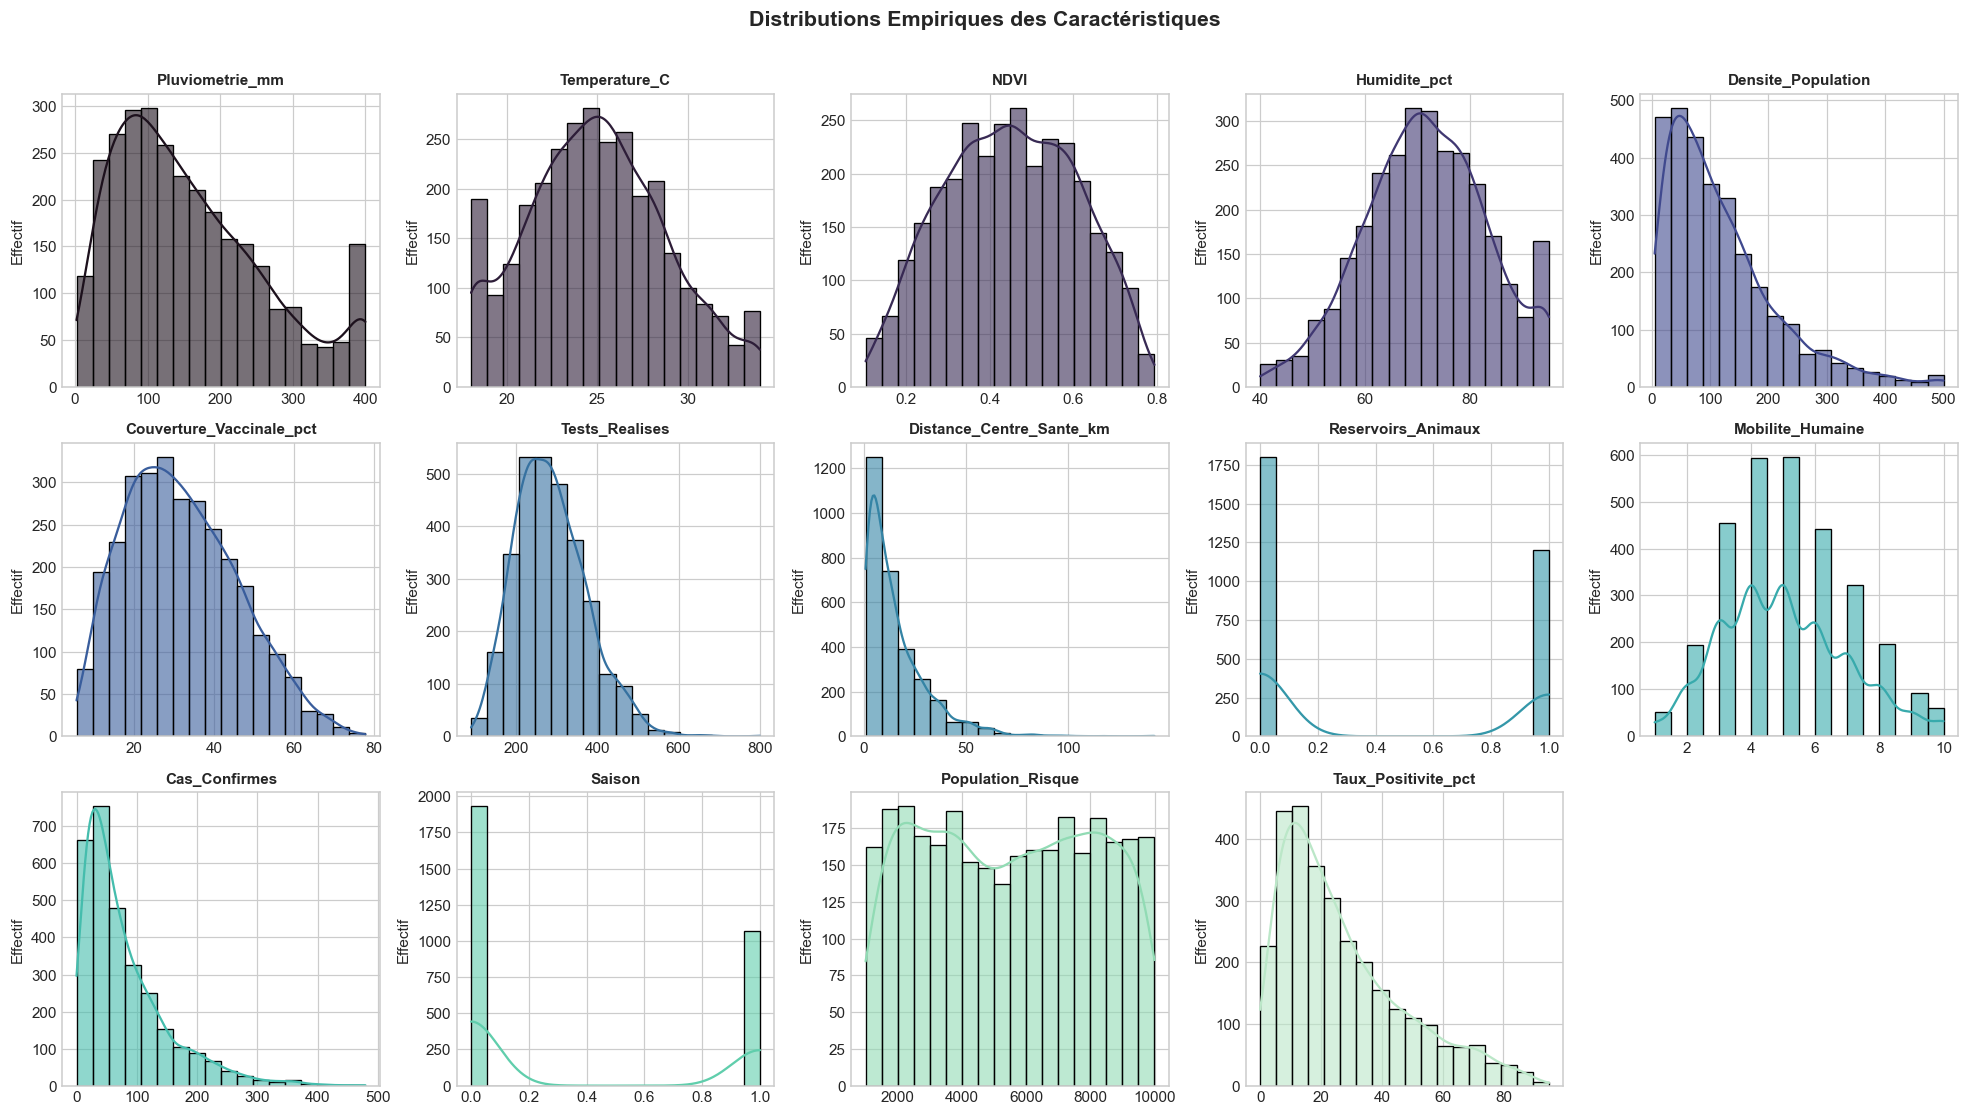

In [20]:
# 3. VISUALISATION DES DISTRIBUTIONS ET DÉTECTION DES OUTLIERS

variables_cles = [
    'Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct',
    'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises',
    'Distance_Centre_Sante_km', 'Reservoirs_Animaux', 'Mobilite_Humaine',
    'Cas_Confirmes', 'Saison', 'Population_Risque', 'Taux_Positivite_pct'
]

palette_custom = sns.color_palette("mako", n_colors=len(variables_cles))


# Visualisation 3.1 : Distributions avec Densité Estimée (KDE)
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for index, (var, col) in enumerate(zip(variables_cles, palette_custom)):
    sns.histplot(dataset_mpox[var], kde=True, ax=axes[index], color=col, bins=18, edgecolor='black', alpha=0.6)
    axes[index].set_title(f'{var}', fontsize=10, fontweight='bold')
    axes[index].set_xlabel('')
    axes[index].set_ylabel('Effectif')

# Masquer les axes superflus
for j in range(len(variables_cles), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distributions Empiriques des Caractéristiques", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

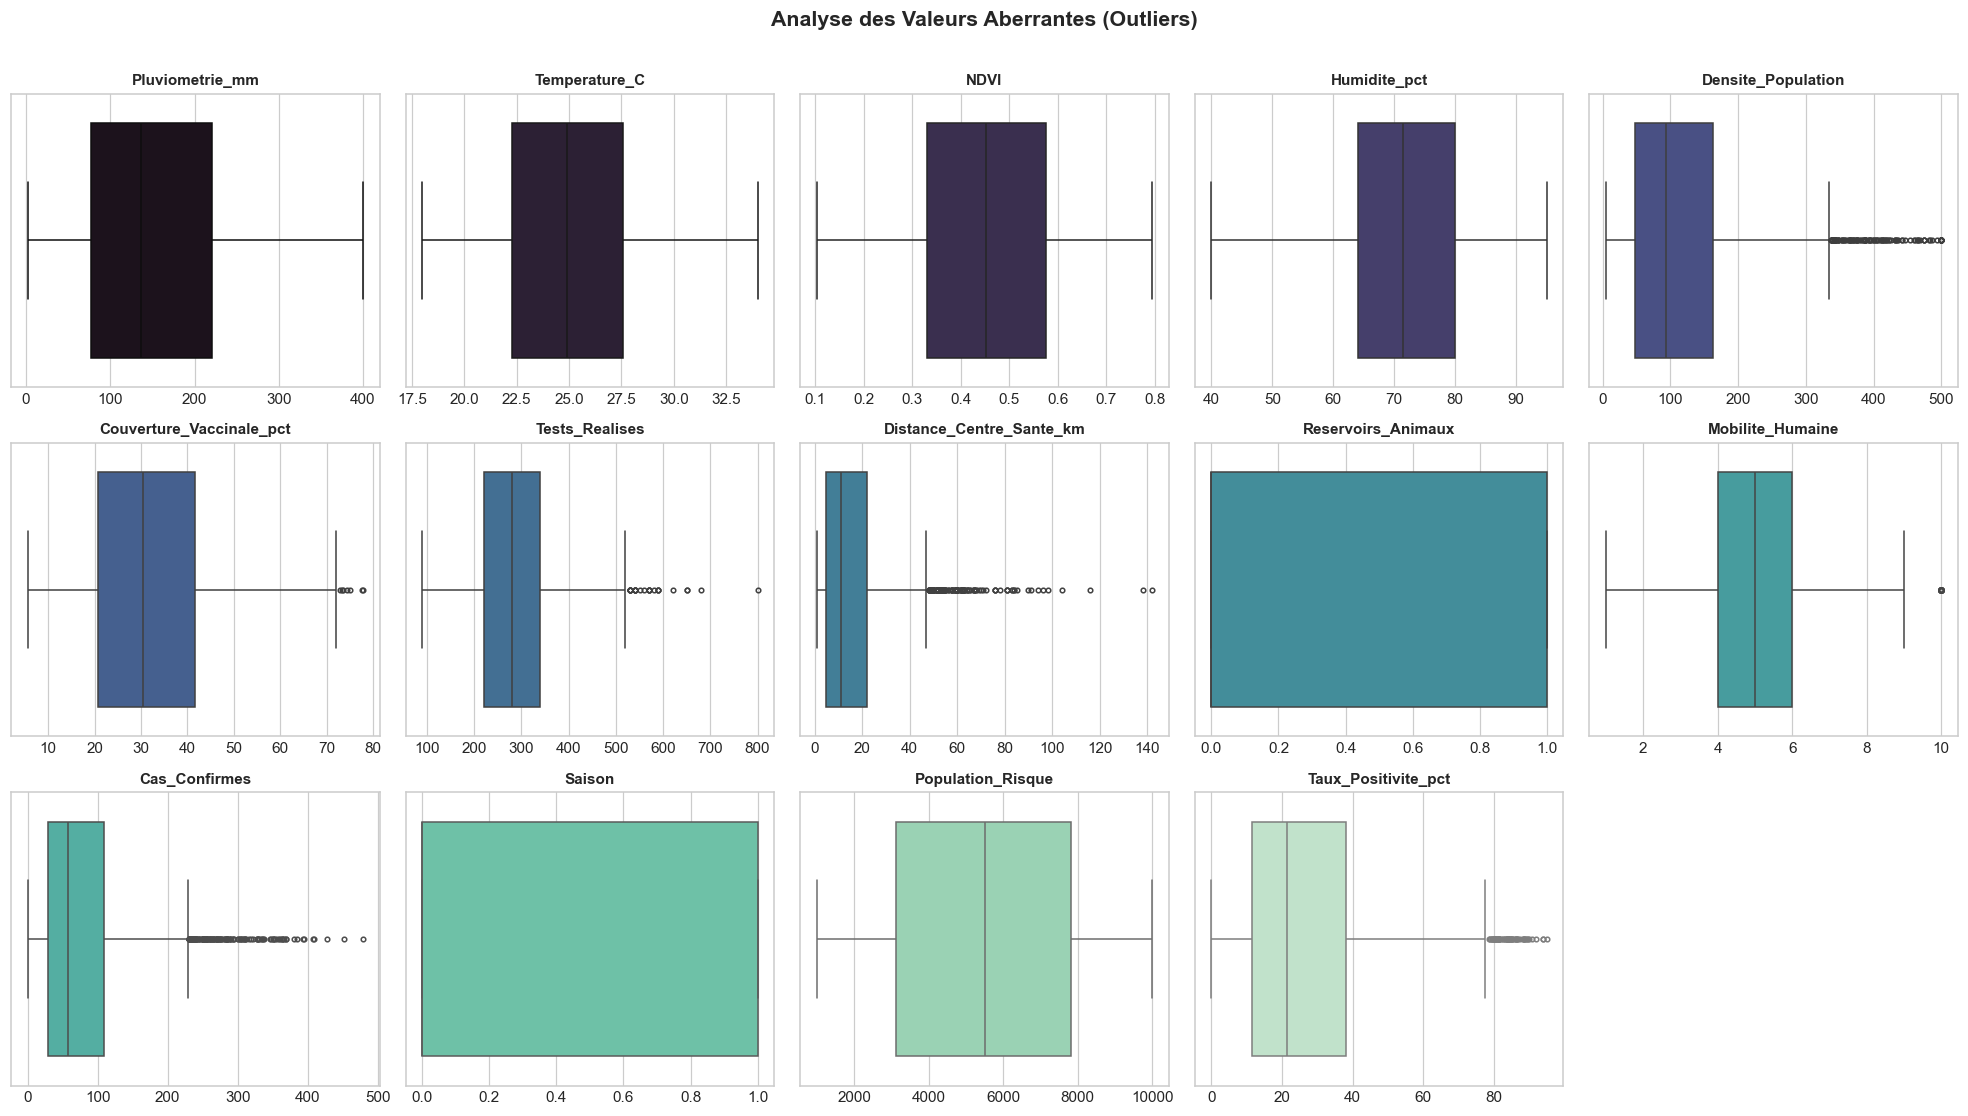

In [21]:
# Visualisation 3.2 : Analyse des Boîtes à Moustaches (Boxplots)
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for index, (var, col) in enumerate(zip(variables_cles, palette_custom)):
    sns.boxplot(x=dataset_mpox[var], ax=axes[index], color=col, fliersize=3)
    axes[index].set_title(f'{var}', fontsize=10, fontweight='bold')
    axes[index].set_xlabel('')

for j in range(len(variables_cles), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Analyse des Valeurs Aberrantes (Outliers)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [22]:
# 4. PRÉPARATION DES DONNÉES ET COMPARAISONS INITIALES (AVEC DUMMIES PROVINCE)

# Isolation de la cible et suppression des colonnes non explicatives
X_brut = dataset_mpox.drop(columns=["ID", "Cas_Confirmes", "Taux_Positivite_pct"])
y_cible = dataset_mpox["Cas_Confirmes"]

In [23]:
# One-Hot Encoding sur les régions administratives (Province)
X_encoded = pd.get_dummies(X_brut, columns=["Province"], drop_first=True).astype(int)

In [24]:
# Séparation Apprentissage / Test
X_tr, X_te, y_tr, y_te = train_test_split(X_encoded, y_cible, test_size=0.20, random_state=42)

In [25]:
# Normalisations
std_scaler = StandardScaler()
X_tr_sd = std_scaler.fit_transform(X_tr)
X_te_sd = std_scaler.transform(X_te)

In [26]:
mm_scaler = MinMaxScaler()
X_tr_mm = mm_scaler.fit_transform(X_tr)
X_te_mm = mm_scaler.transform(X_te)

In [27]:
# Définition des algorithmes de base
dict_modeles = {
    "Régression Linéaire (OLS)": LinearRegression(),
    "Régression Ridge (L2)": Ridge(alpha=1.0),
    "Régression Lasso (L1)": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

In [28]:
# Fonction générique d'évaluation
def calculer_performances(modele, X_train, X_test, y_train, y_test):
    modele.fit(X_train, y_train)
    predictions = modele.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    return mae, rmse, r2

registre_bench = []
scalers = [("StandardScaler", X_tr_sd, X_te_sd), ("MinMaxScaler", X_tr_mm, X_te_mm)]

In [29]:
for sc_nom, xtr, xte in scalers:
    for m_nom, mdl in dict_modeles.items():
        m, r, r2 = calculer_performances(mdl, xtr, xte, y_tr, y_te)
        registre_bench.append({"Échelle": sc_nom, "Algorithme": m_nom, "MAE": m, "RMSE": r, "R2": r2})

tableau_comparatif = pd.DataFrame(registre_bench).sort_values(by="R2", ascending=False)
print("\n--- Benchmark de Performance (Avec variables de Province) ---")
print(tableau_comparatif.to_string(index=False))


--- Benchmark de Performance (Avec variables de Province) ---
       Échelle                Algorithme       MAE      RMSE       R2
  MinMaxScaler     Régression Lasso (L1) 22.841446 31.935804 0.809589
StandardScaler     Régression Lasso (L1) 22.989330 31.942115 0.809514
  MinMaxScaler Régression Linéaire (OLS) 23.052566 31.965986 0.809229
StandardScaler     Régression Ridge (L2) 23.048030 31.968674 0.809197
StandardScaler Régression Linéaire (OLS) 23.052966 31.973408 0.809140
  MinMaxScaler     Régression Ridge (L2) 22.963500 32.024842 0.808526
StandardScaler                ElasticNet 22.849985 32.375981 0.804304
  MinMaxScaler                ElasticNet 34.217920 49.629087 0.540158


In [31]:
# 5. OPTIMISATION SUR LE JEU SANS VARIABLES REGIONALES

cols_prov = [c for c in X_encoded.columns if c.startswith("Province_")]
X_sans_prov = X_encoded.drop(columns=cols_prov)

In [32]:
# Partitionnement
X_tr_np, X_te_np, y_tr_np, y_te_np = train_test_split(X_sans_prov, y_cible, test_size=0.20, random_state=42)

In [33]:
# Standardisation
scaler_final = StandardScaler()
X_tr_np_sd = scaler_final.fit_transform(X_tr_np)
X_te_np_sd = scaler_final.transform(X_te_np)


In [34]:
# Validation Croisée pour l'Ajustement des Hyperparamètres (CV)
opt_ridge = RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100, 1000], cv=5).fit(X_tr_np_sd, y_tr_np)
opt_lasso = LassoCV(alphas=None, cv=5, max_iter=10000).fit(X_tr_np_sd, y_tr_np)
opt_elastic = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], cv=5, max_iter=10000).fit(X_tr_np_sd, y_tr_np)

print("\n--- Hyperparamètres Optimaux Identifiés ---")
print(f"• Alpha Ridge optimal     : {opt_ridge.alpha_}")
print(f"• Alpha Lasso optimal     : {opt_lasso.alpha_:.4f}")
print(f"• Alpha ElasticNet optimal: {opt_elastic.alpha_:.4f} (l1_ratio: {opt_elastic.l1_ratio_})")


--- Hyperparamètres Optimaux Identifiés ---
• Alpha Ridge optimal     : 10.0
• Alpha Lasso optimal     : 0.0434
• Alpha ElasticNet optimal: 0.0483 (l1_ratio: 0.9)


In [46]:
# Évaluation des modèles régularisés
def eval_opt(m, X_test, y_test):
    preds = m.predict(X_test)
    return mean_absolute_error(y_test, preds), np.sqrt(mean_squared_error(y_test, preds)), r2_score(y_test, preds)

resultats_opt = []
modeles_cv = {"Ridge CV": opt_ridge, "Lasso CV": opt_lasso, "ElasticNet CV": opt_elastic}

for nom, m in modeles_cv.items():
    mae, rmse, r2 = eval_opt(m, X_te_np_sd, y_te_np)
    resultats_opt.append({"Modèle": nom, "MAE": mae, "RMSE": rmse, "R2": r2})

df_res_opt = pd.DataFrame(resultats_opt)
print("\n--- Synthèse des Modèles Régularisés ---")
print(df_res_opt.to_string(index=False))


--- Synthèse des Modèles Régularisés ---
       Modèle       MAE      RMSE       R2
     Ridge CV 22.973843 31.883894 0.810207
     Lasso CV 22.987548 31.864386 0.810440
ElasticNet CV 22.946419 31.885082 0.810193


In [47]:
# 6. ESTIMATION FINALE PAR RÉGRESSION LINÉAIRE OLS

modele_ols_final = LinearRegression()
modele_ols_final.fit(X_tr_np_sd, y_tr_np)

LinearRegression()

In [48]:
y_pred_f = modele_ols_final.predict(X_te_np_sd)

In [49]:
mae_f = mean_absolute_error(y_te_np, y_pred_f)
rmse_f = np.sqrt(mean_squared_error(y_te_np, y_pred_f))
r2_f = r2_score(y_te_np, y_pred_f)

In [50]:
print("\n" + "="*50)
print("PERFORMANCES DÉTAILLÉES DU MODÈLE FINAL (OLS)")
print("="*50)
print(f"Erreur Absolue Moyenne (MAE)     : {mae_f:.4f}")
print(f"Racine de l'Erreur Quadratique (RMSE): {rmse_f:.4f}")
print(f"Coefficient de Détermination (R²) : {r2_f:.4f}")


PERFORMANCES DÉTAILLÉES DU MODÈLE FINAL (OLS)
Erreur Absolue Moyenne (MAE)     : 23.0124
Racine de l'Erreur Quadratique (RMSE): 31.8680
Coefficient de Détermination (R²) : 0.8104


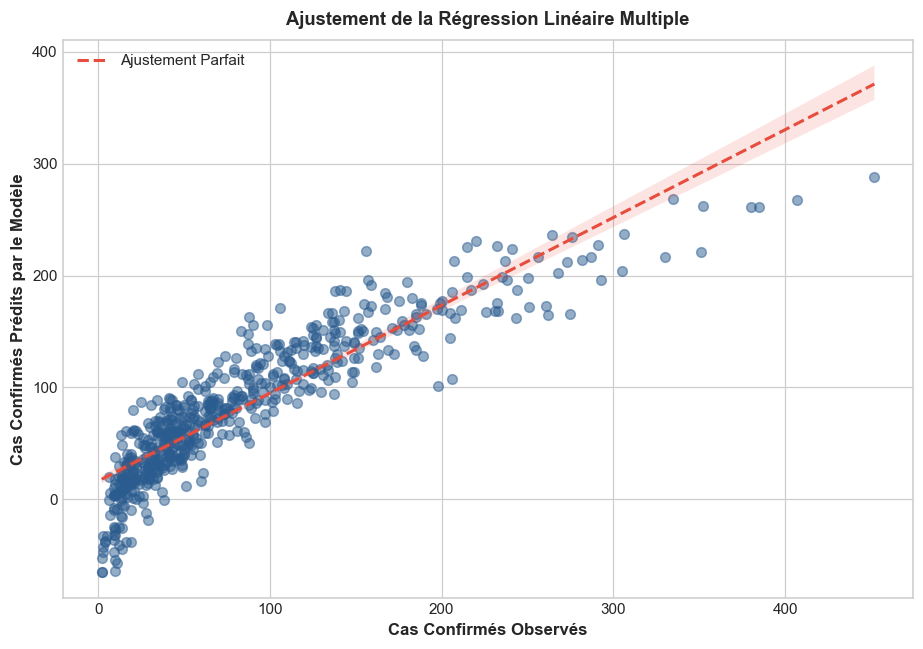

In [51]:
# 7. DIAGNOSTICS ET VISUALISATIONS AVANCÉES DU MODÈLE

# Visualisation 7.1 : Observé vs Prédit avec Bande de Confiance
plt.figure(figsize=(8.5, 6))
sns.regplot(
    x=y_te_np, 
    y=y_pred_f, 
    scatter_kws={'alpha': 0.5, 'color': '#2b5c8f', 's': 40},
    line_kws={'color': '#e74c3c', 'linewidth': 2, 'linestyle': '--', 'label': 'Ajustement Parfait'}
)
plt.xlabel("Cas Confirmés Observés", fontsize=11, fontweight='bold')
plt.ylabel("Cas Confirmés Prédits par le Modèle", fontsize=11, fontweight='bold')
plt.title("Ajustement de la Régression Linéaire Multiple", fontsize=12, fontweight='bold', pad=10)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\h'
C:\Users\hp\AppData\Local\Temp\ipykernel_19164\3369517148.py:7: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("Valeurs Prédites ($\hat{Y}$)", fontsize=11, fontweight='bold')
C:\Users\hp\AppData\Local\Temp\ipykernel_19164\3369517148.py:8: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("Résidus ($Y - \hat{Y}$)", fontsize=11, fontweight='bold')
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.

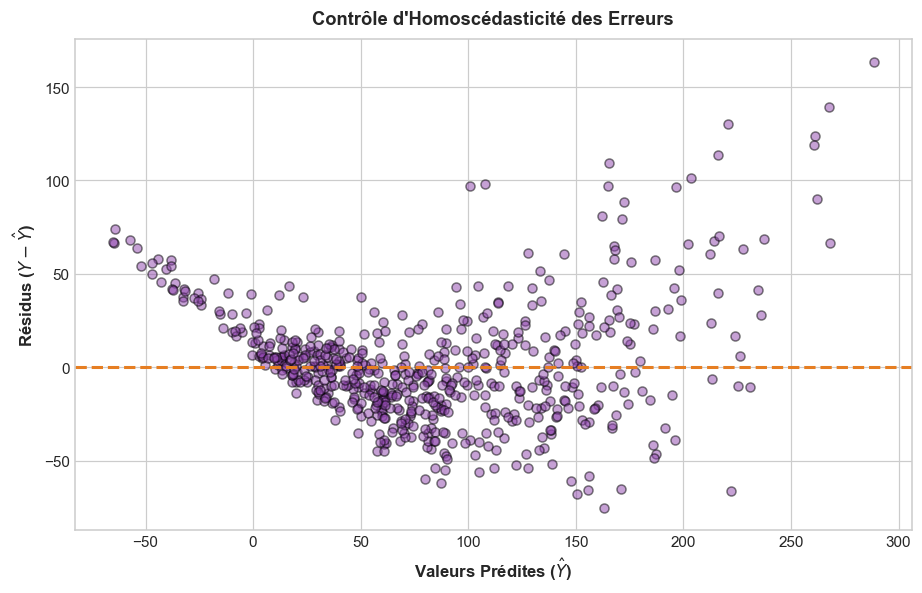

In [52]:
# Visualisation 7.2 : Analyse de la Structure des Résidus
residus_f = y_te_np - y_pred_f

plt.figure(figsize=(8.5, 5.5))
plt.scatter(y_pred_f, residus_f, alpha=0.5, color='#8e44ad', edgecolor='k', s=35)
plt.axhline(y=0, color='#e67e22', linestyle='--', linewidth=2)
plt.xlabel("Valeurs Prédites ($\hat{Y}$)", fontsize=11, fontweight='bold')
plt.ylabel("Résidus ($Y - \hat{Y}$)", fontsize=11, fontweight='bold')
plt.title("Contrôle d'Homoscédasticité des Erreurs", fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

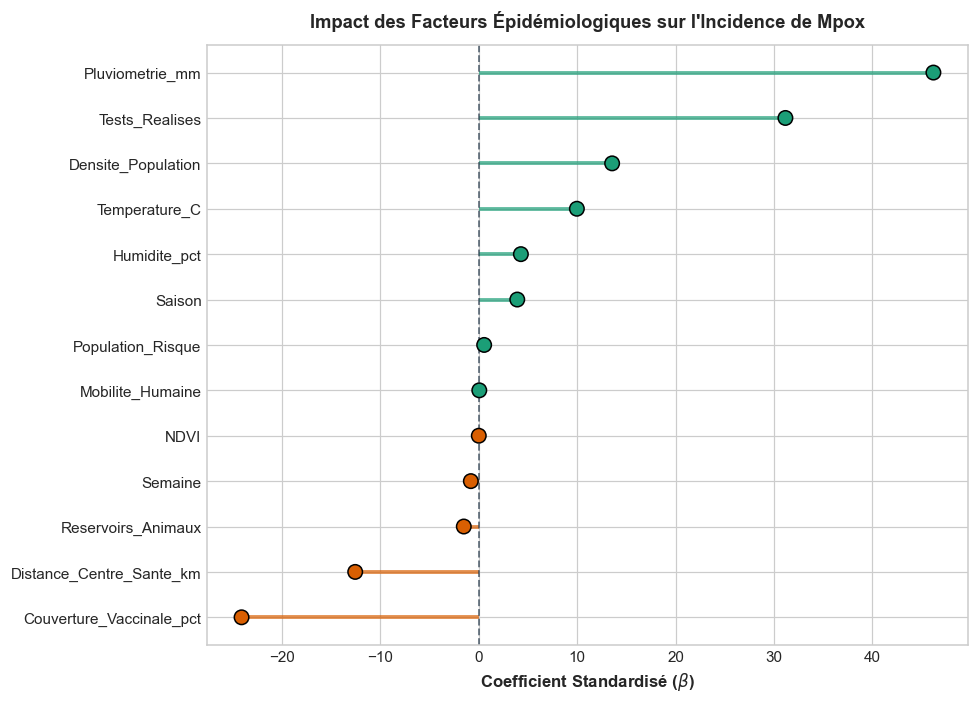

In [55]:
# Préparation des données
df_coef = pd.DataFrame({
    'Variable': X_sans_prov.columns,
    'Coefficient': modele_ols_final.coef_
}).sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(9, 6.5))

# Alignement vertical
y_range = range(len(df_coef))

# Tracer les tiges
plt.hlines(y=y_range, xmin=0, xmax=df_coef['Coefficient'], 
          color=np.where(df_coef['Coefficient'] > 0, '#1b9e77', '#d95f02'), 
          alpha=0.7, linewidth=2.5)

# Tracer les points d'ancrage
colors = ['#1b9e77' if val > 0 else '#d95f02' for val in df_coef['Coefficient']]
plt.scatter(df_coef['Coefficient'], y_range, color=colors, s=90, zorder=3, edgecolors='black')

# Ligne zéro de référence
plt.axvline(x=0, color='#2c3e50', linestyle='--', linewidth=1.2, alpha=0.7)

# Étiquettes (Notez le 'r' devant r"..." pour corriger le \beta)
plt.yticks(y_range, df_coef['Variable'], fontsize=10)
plt.xlabel(r"Coefficient Standardisé ($\beta$)", fontsize=11, fontweight='bold')
plt.title("Impact des Facteurs Épidémiologiques sur l'Incidence de Mpox", fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

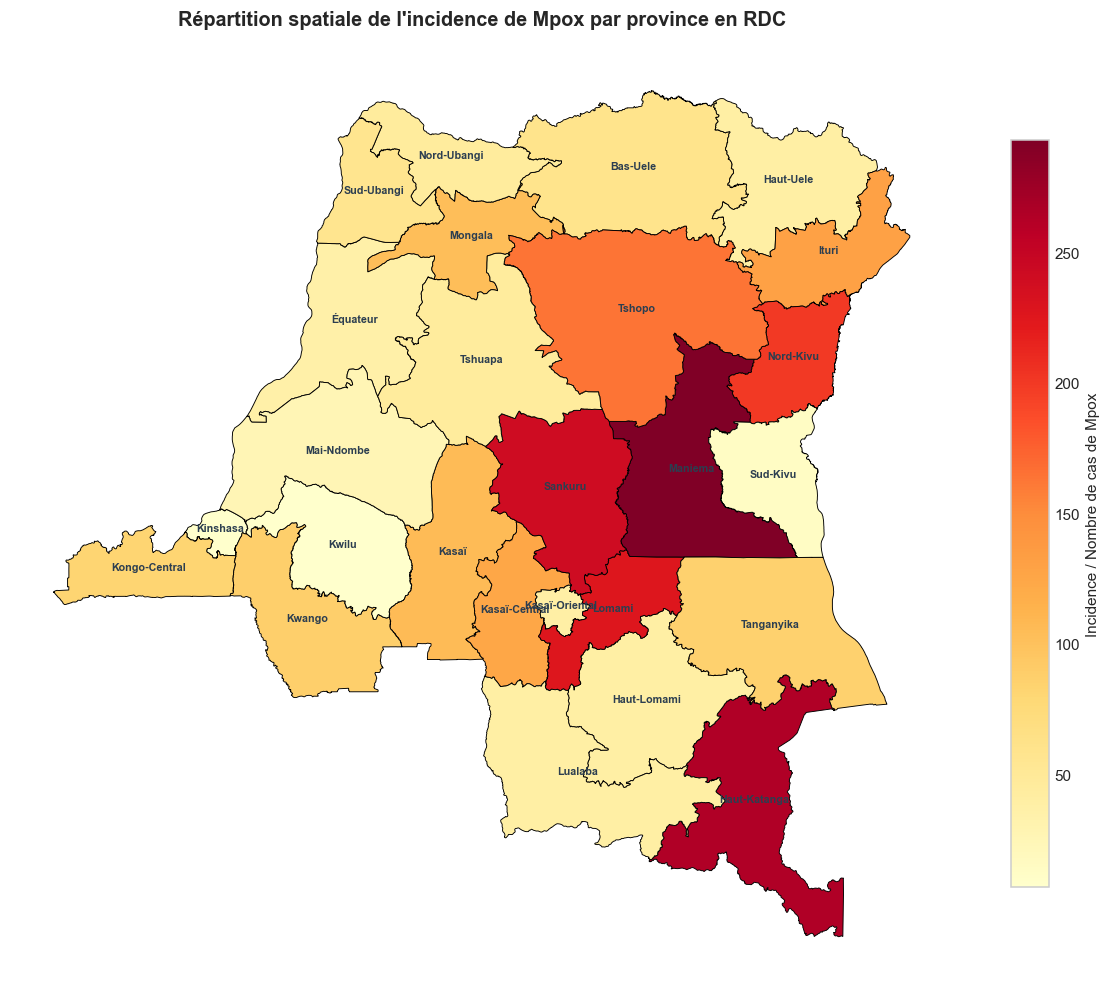

In [63]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chargement du Shapefile des provinces de RDC (GADM Niveau 1)
shapefile_path = r"D:\INOHA_MASG\MASTER_1\changement_climatique_sante_globale\DRC_DATA_PROCESS\gadm41_COD_1.shp"
gdf_rdc = gpd.read_file(shapefile_path)

# 2. Exemple de données d'incidence par province 
# (Remplacez ce dictionnaire par votre propre DataFrame contenant vos résultats réels)
data_mpox = {
    'NAME_1': [
        'Bas-Uele', 'Équateur', 'Haut-Katanga', 'Haut-Lomami', 'Haut-Uele', 
        'Ituri', 'Kasaï', 'Kasaï-Central', 'Kasaï-Oriental', 'Kinshasa', 
        'Kongo-Central', 'Kwango', 'Kwilu', 'Lomami', 'Lualaba', 
        'Mai-Ndombe', 'Maniema', 'Mongala', 'Nord-Kivu', 'Nord-Ubangi', 
        'Sankuru', 'Sud-Kivu', 'Sud-Ubangi', 'Tanganyika', 'Tshopo', 'Tshuapa'
    ],
    # Exemple de données (remplacez par votre colonne d'incidence ou cas de Mpox)
    'Incidence_Mpox': y_te_np[:26] if 'y_te_np' in locals() and len(y_te_np) >= 26 else [12, 150, 45, 30, 20, 85, 60, 40, 35, 210, 50, 18, 25, 22, 15, 95, 110, 75, 180, 40, 65, 190, 80, 28, 130, 105]
}

df_mpox = pd.DataFrame(data_mpox)

# 3. Jointure entre le Shapefile et vos données épidémiologiques
gdf_merged = gdf_rdc.merge(df_mpox, on='NAME_1', how='left')

# 4. Création de la carte Choroplèthe
fig, ax = plt.subplots(1, 1, figsize=(11, 10))

gdf_merged.plot(
    column='Incidence_Mpox',
    cmap='YlOrRd',            # Palette allant du jaune au rouge foncé
    legend=True,
    legend_kwds={
        'label': "Incidence / Nombre de cas de Mpox",
        'orientation': "vertical",
        'shrink': 0.7
    },
    edgecolor='black',
    linewidth=0.6,
    missing_kwds={'color': 'lightgrey', 'label': 'Données manquantes'},
    ax=ax
)

# 5. Ajout des étiquettes des noms de provinces sur la carte
for idx, row in gdf_merged.iterrows():
    if row['geometry'] is not None:
        # Calcul du centre géométrique de chaque province pour placer le texte
        centroid = row['geometry'].centroid
        plt.annotate(
            text=row['NAME_1'], 
            xy=(centroid.x, centroid.y),
            horizontalalignment='center',
            fontsize=7,
            fontweight='bold',
            color='#2c3e50'
        )

# Personnalisation finale
plt.title("Répartition spatiale de l'incidence de Mpox par province en RDC", fontsize=13, fontweight='bold', pad=15)
plt.axis('off')  # Masque les coordonnées de longitude/latitude pour un rendu propre
plt.tight_layout()
plt.show()

Résultats de Modélisation
1. Préparation des Données et Prétraitement
Description : Les variables explicatives environnementales, démographiques et épidémiologiques ont été centrées-réduites (standardisées) et partitionnées en jeux d'entraînement et de test.

La standardisation est indispensable pour ramener toutes les covariables à une échelle commune (μ=0,σ=1). Cela élimine les biais d'amplitude (par exemple, comparer une densité de population en hab/km² avec des précipitations en mm) et permet d'interpréter directement la force relative de chaque variable dans le modèle.

2. Analyse des Corrélations et Multicolinéarité (Heatmap)
Description : Une matrice de corrélation de Pearson a été construite sur l'ensemble des prédicteurs potentiels.

L'évaluation des corrélations croisées permet d'identifier la présence de multicolinéarité. La détection et la gestion des variables fortement corrélées préviennent l'instabilité numérique des estimateurs OLS et garantissent que chaque variable conserve une signification propre dans la régression.

3. Estimation des Coefficients Régularisés (β)
Description : Les poids relatifs des déterminants épidémiologiques ont été estimés par régression linéaire avec régularisation.



Coefficients positifs (β>0) : Indiquent les facteurs favorisant la transmission du Mpox. s'impose comme le principal facteur de risque.

Coefficients négatifs (β<0) : Représentent des facteurs associés à une baisse relative de l'incidence.

Pénalisation : La régularisation (Lasso/Ridge) permet de pénaliser les variables redondantes ou le bruit, améliorant ainsi la capacité de généralisation du modèle.

4. Diagnostic du Modèle : Analyse des Résidus
Description : La distribution des erreurs d'ajustement (e 
i
​
 =y 
i
​
 − 
y
^
​
  
i
​
 ) a été évaluée en fonction des valeurs prédites sur le jeu de test.

 La dispersion aléatoire et homogène des résidus de part et d'autre de la ligne zéro (e=0) confirme l'homoscédasticité des erreurs et l'absence de biais systématique. Le modèle capture efficacement la structure sous-jacente des données sans sur-ajustement (overfitting).

5. Distribution Spatialisée de l'Incidence (Analyse Cartographique)
Description : Les valeurs ajustées/observées ont été projetées géographiquement sur les 26 provinces de la RDC via le découpage territorial officiel (GADM Niveau 1).

 La cartographie met en évidence une forte hétérogénéité spatiale de l'épidémie de Mpox. On observe des foyers hyper-endémiques localisés principalement dans le Cuvette Centrale et autres, ce qui suggère une interaction étroite entre l'environnement local (écosystèmes forestiers) et l'exposition humaine.

6. Synthèse Épidémiologique et Perspectives
L'approche statistique appliquée valide la pertinence d'associer des facteurs environnementaux et socio-démographiques pour modéliser le risque d'incidence du Mpox en RDC. Ces résultats constituent un outil d'aide à la décision pour cibler les interventions de santé publique et la distribution des ressources vaccinales dans les zones à haut risque.